# Autor: Daniela Déniz Viera

Esto es un TFM para encontrar cúmulos de estrellas mediante el algoritmo de aprendizaje no supervisado dbscan. Los datos que se van a utilizar son los proporcionados por Gaia, una misión de la ESA encargada de hacer un "mapa" de las estrellas de nuestra galaxia. En concreto en este TFM utilizaremos la base de datos del tercer release: Gaia DR3.

# Paquetes

In [576]:
!pip install astroquery

In [577]:
!pip install hdbscan

In [578]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from astroquery.gaia import Gaia
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import hdbscan
from sklearn.metrics import silhouette_score
from hdbscan.validity import validity_index

# Descarga de datos

Lo primero que tendremos que hacer, es descagar los datos. Un módulo de python ha sido desarrollado para poder extraer datos de los data set de manera sencilla. En nustro caso, vamos a descargar datos centrándonos en regiones concretas del espacio, con el objetivo de hacer el problema computacionalmente más sencillo. Para ello vamos a utilizar una búsqueda en forma de "cono". Mediante el right ascencion y la declination describimos el punto central del cono y mediante el radio, el área que comprende ese cono de búsqueda.

In [579]:
# función para descargar datos de Gaia DR3
def descargar_gaia_region(ra,dec,radio=2.0,g_max=18,parallax_min=None,parallax_max=None,max_rows=50000,output_csv=None):
    """
    Parámetros:
    - ra, dec: centro de la región(right ascension y declination).[deg]
    - radio_deg: radio del cono de la región. [deg]
    - g_max: magnitud máxima Gaia G.
    - parallax_min/parallax_max: filtros opcionales de paralaje. [mas](milisegundo de arco)
    - max_rows: número máximo de filas descargadas.
    """

    parallax_filter = ""

    if parallax_min is not None:
        parallax_filter += f" AND parallax >= {parallax_min}"

    if parallax_max is not None:
        parallax_filter += f" AND parallax <= {parallax_max}"

    query = f"""
    SELECT TOP {max_rows}
        source_id,ra,dec,
        parallax,parallax_error,
        pmra,pmra_error,
        pmdec,pmdec_error,
        phot_g_mean_mag,bp_rp,ruwe
    FROM gaiadr3.gaia_source
    WHERE
        1 = CONTAINS(
            POINT('ICRS', ra, dec),
            CIRCLE('ICRS', {ra}, {dec}, {radio}))
        AND parallax IS NOT NULL
        AND pmra IS NOT NULL
        AND pmdec IS NOT NULL
        AND phot_g_mean_mag < {g_max}
        AND ruwe < 1.4
        AND parallax_over_error > 5
        {parallax_filter}
    """

    job = Gaia.launch_job_async(query)
    table = job.get_results()

    df = table.to_pandas()

    if output_csv:
        df.to_csv(output_csv, index=False)

    return df

En la función anterior, preparamos un query para pedir datos a la base de datos de Gaia. Incluimos los siguientes parámetros en la query:
- Source_id : identificador único del objeto
- ra : nodo ascendente
- deg: declination
- pmra: movimiento propio en la dirección del nodo ascendente
- pmra_error: error estándar del movimiento propio en la dirección del nodo ascendente
- pmdec: movimiento propio en la dirección de la declinación
- pmdec: error estándar del movimiento propio en la dirección de la declinación
- phot_g_mean_mag: magnitud media en la banda G
- bp_rp : color bp_rp
- ruwe : magnitud global de error

Hemos escogido estas magnitudes por que son las más representativas sobre los cúmulos de estrellas que usarán nuestros algorítmos de clustering. Otras magnitudes nos sirven para comparar los resultados con observaciones astronómicas.

In [580]:
# función para seleccionar variables concretas y obtener un subset de datos
def seleccionar_variables(df, variables):
    df_vars = df[variables].copy()
    df_vars = df_vars.dropna()

    return df_vars

Vamos ahora a descargar los datos de una región en concreto. Para ello, nos centraremos en la región conocida como las Pléyades. Cuyo centro es (56.75,24.12).A demás hemos elegido un radio de 3 grados al rededor de la región. Las Pleyádes se encuentran a unos 7 mas de distancia, por eso hemos elegido un paralaje mínimo de 5 mas y uno máximo de 10 mas.

In [581]:
df = descargar_gaia_region(
    ra=56.75,
    dec=24.12,
    radio=3.0,
    g_max=18,
    parallax_min=5,
    parallax_max=10,
    output_csv="gaia_pleyades_region.csv")
print(df.shape)
print(df.head())

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
(1897, 12)
           source_id         ra        dec  parallax  parallax_error  \
0  63589159777315072  56.509703  21.633659  7.188346        0.042911   
1  63592630110894208  56.330068  21.702064  7.596332        0.080201   
2  63676192995841664  57.996858  21.454817  5.542660        0.083018   
3  63735016867881600  57.908746  21.789648  5.201661        0.093648   
4  63834282152243840  58.218430  21.972159  7.462313        0.015256   

        pmra  pmra_error       pmdec  pmdec_error  phot_g_mean_mag     bp_rp  \
0   8.288472    0.043267   -0.562731     0.030370        15.303451  2.250832   
1  57.254307    0.090696   -3.005735     0.068919        16.929272  2.727583   
2  11.124766    0.096651  -10.544296     0.065153        17.241972  3.047993   
3  27.352203    0.106630  -20.623813     0.071661        17.289030  3.090078   
4  94.684358    0.019211 -102.167391     0.011265         9.876052  0.879712   

       ruwe  
0  1.040024

In [582]:
variable = ["ra", "dec", "parallax", "pmra", "pmdec"]
df_vars = seleccionar_variables(df, variable)
df_vars.head()

,ra,dec,parallax,pmra,pmdec
0,56.509703,21.633659,7.188346,8.288472,-0.562731
1,56.330068,21.702064,7.596332,57.254307,-3.005735
2,57.996858,21.454817,5.542660,11.124766,-10.544296
3,57.908746,21.789648,5.201661,27.352203,-20.623813
4,58.218430,21.972159,7.462313,94.684358,-102.167391


Hemos elegido estas features porque son las más representativas para identificar cúmulos de estrellas, el resto de variables que hemos pedido en la query las usaremos a modo de validación más adelante.

# Feature engineering / EDA

Antes de poder utilizar los datos en nuestros algoritmos de clustering, tenemos que transformar los datos, para que los algoritmos no se vean afectados debido a las irregularidades de estos. Los algoritmos de clustering, se basan mayoritariamente en la distancia entre los objetos que quiere clasificar. Nuestras variables, están en escalas completamente diferentes, pudiendo significar que las variables con mayor escala, pueden eclipsar al resto. Es por esto, que vamos a escalar las variables para que así sean utilizadas en igual medida por los algoritmos.

A demás, vamos hacer una análisis exploratorio de los datos para hacernos una idea de la forma que tienen nuestras variables, y así poder sacar conclusiones de valor para luego introducirlas en los algoritmos.

In [583]:
# eda básico
df_vars.describe()

,ra,dec,parallax,pmra,pmdec
count,1897.000000,1897.000000,1897.000000,1897.000000,1897.000000
mean,56.695964,24.147148,6.973952,20.098273,-38.127989
std,1.414351,1.318385,0.995862,32.784748,25.849222
min,53.494944,21.143075,5.000687,-159.597971,-289.844289
25%,55.734399,23.217884,6.274822,16.272073,-46.260036
50%,56.669225,24.116067,7.266634,19.715960,-44.527818
75%,57.685729,25.094267,7.474582,21.313118,-25.704884
max,59.996547,27.089484,9.939184,611.108247,80.316281


Arriba podemos ver un análisis estadístico básico de las variables que vamos a utilizar para identificar los cúmulos. Podemos ver que las variables tienen rangos bastante diferentes, por lo que más adelante tendremos que estandarizarlas. Por otro lado, vemos que los valores del nodo ascendente y de la declinación tienen sentido con respecto a lo que hemos pedido a través de la query. El paralaje también comprende el rango que hemos especificado en la query. En cuanto al movimiento propio, vemos que hay un rango bastante amplio de valores, ya que en general, el movimiento de las estrellas varía mucho.

Vamos ahora a apoyar las conclusiones que hemos sacado mediante la visualización de los datos en histogramas.

In [584]:
def plot_histogramas(df):
    variables = ["ra","dec","parallax", "pmra", "pmdec"]
    titles = ["Nodo ascendente", "Declinación", "Paralaje", "PMra", "PMdec"]

    plt.figure(figsize=(15, 4))

    for i, var in enumerate(variables, 1):
        plt.subplot(1, 5, i)
        plt.title(titles[i-1])

        sns.histplot(
            df[var],
            bins=50,
            kde=True
        )
        plt.xlabel(var)

    plt.tight_layout()
    plt.show()

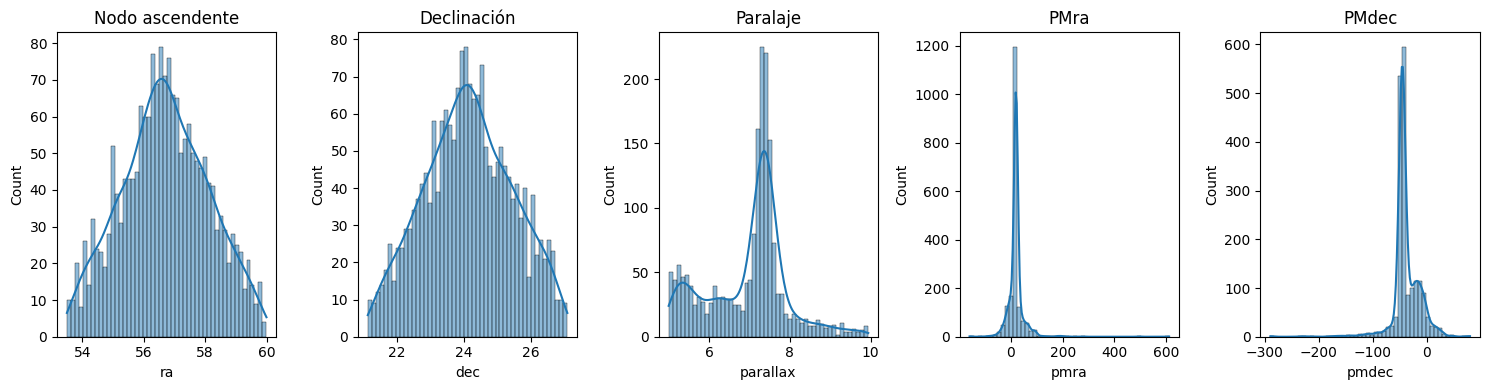

In [585]:
plot_histogramas(df_vars)

En los histogramas podemos ver los diferentes rangos de las variables. A demás también se observa un pico bastante pronunciado en todos los histogramas. Este pico coincide exactamente con la posición y la disancia del cúmulo Pléyades ya que los datos están centrados a su alrededor.

Una vez hecho esto, vamos a representar la posición en el cielo de las estrellas para ver cómo están distribuidas. Para ello representamos las coordenadas que describen su posición, es decir, el nodo ascendente y la declinación.

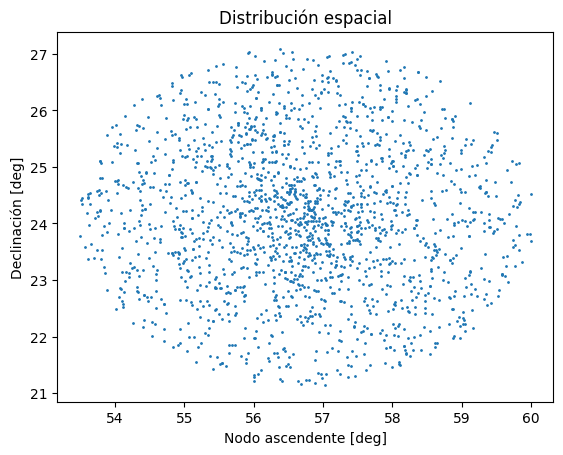

In [586]:
plt.scatter(df["ra"], df["dec"], s=1)
plt.xlabel("Nodo ascendente [deg]")
plt.ylabel("Declinación [deg]")
plt.title("Distribución espacial")
plt.show()

Podemos ver  en el centro una región claramente densa. Otra forma de ver el cúmulo de una manera incluso más clara es representando su movimiento propio. Las estrellas de un cúmulo nacen a la vez, por lo que están ligadas gravitacionalmente, y esto hace que se muevan con velocidades muy similares.

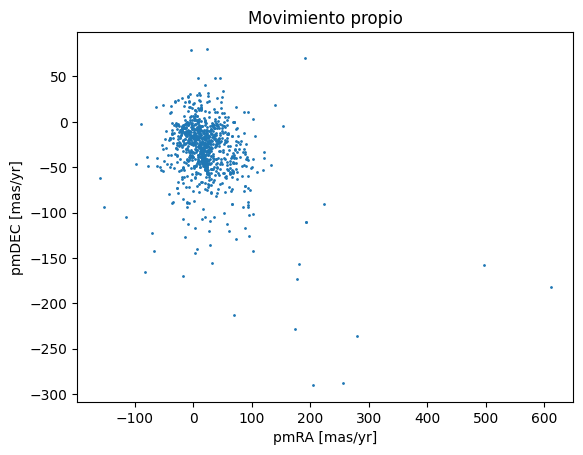

In [587]:
plt.scatter(df["pmra"], df["pmdec"], s=1)
plt.xlabel("pmRA [mas/yr]")
plt.ylabel("pmDEC [mas/yr]")
plt.title("Movimiento propio")
plt.show()

Vemos claramente un cúmulo.

Este gráfico representa un diagrama color–magnitud, aproximación observacional del diagrama de Hertzsprung-Russell diagram, donde se muestra la relación entre el color de las estrellas (bp_rp, indicador de su temperatura superficial) y su magnitud en la banda G. En este tipo de diagramas, las estrellas de un cúmulo abierto como las Pléyades tienden a distribuirse siguiendo una secuencia bien definida, conocida como secuencia principal, debido a que comparten edad, composición química y distancia, siendo la masa el principal factor diferenciador de sus propiedades físicas. Por el contrario, las estrellas de fondo, que pertenecen a distintas poblaciones estelares, aparecen más dispersas. Por tanto, este diagrama no solo permite analizar la estructura física de las estrellas, sino que constituye una herramienta fundamental para validar la pertenencia de las estrellas a un cúmulo tras aplicar algoritmos de clustering, ya que un conjunto real de miembros debe reproducir dicha secuencia característica.

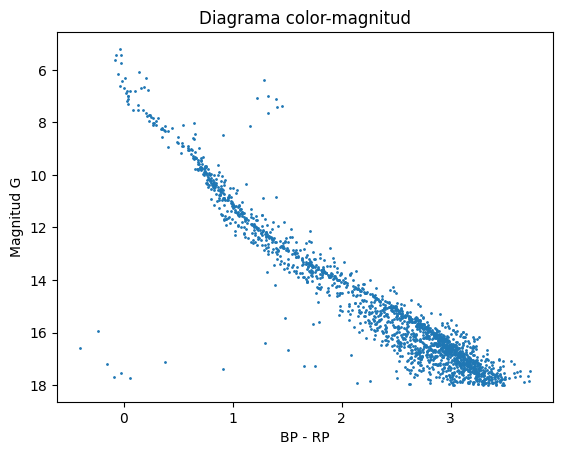

In [588]:
plt.scatter(
    df["bp_rp"],
    df["phot_g_mean_mag"],
    s=1
)

plt.gca().invert_yaxis()
plt.xlabel("BP - RP")
plt.ylabel("Magnitud G")
plt.title("Diagrama color-magnitud")
plt.show()

Pasamos ahora a hacer un feature engineering sencillo : limpieza de datos y estandarización.

In [589]:
def comprobar_nulos(df, features):
    print(f"Valores nulos para la variable {features}:\n")
    print(df[features].isnull().sum())

In [590]:
for var in variable:
    comprobar_nulos(df_vars, var)

Valores nulos para la variable ra:

0
Valores nulos para la variable dec:

0
Valores nulos para la variable parallax:

0
Valores nulos para la variable pmra:

0
Valores nulos para la variable pmdec:

0


No tenemos ningún valor nulo. Era de esperar ya que el conjunto de datos de Gaia es por lo general de bastante calidad y muy limpio. Procedemos ahora a la estandarización de los datos, paso clave, ya que como hemos dicho antes nuestras variables están comprendidas en rangos bastante diferentes

In [591]:
def preparar_clustering(X):
    """
    Escala los datos para clustering.
    """

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled

In [592]:
X_scaled = preparar_clustering(df_vars)

# DBSCAN PLÉYADES

Vamos ahora a diseñar el modelo de DBSCAN. Lo primero será definir unos valores de epsilon y de MinPoints adecuados, ya que de ellos depende la buena performance de nuestro algoritmo. Como tenemos 5 features (dimensionalidad 5) un buen punto de partida para MinPoints será utilizar 10 (MinPoints = 2 x Dim). Una vez elegido el valor de MinPoints, tenemos que elegir el de epsilon. Para ello vamor a utilizar el método de la k-ésima distancia. Este método utiliza un valor de k inicial de MinPoints-1 (9 en nuestro caso). Después calcula la distancia al k-ésimo vecino más cercano a cada punto.Grafica las distancias ordenadas en el eje x, y el índice de los puntos ordenados en el y. Por último el epsilon se elige como el valor donde se aprecia un codo en la curva.

In [593]:
def k_distance_plot(X_scaled, min_samples=10):
    """
    Calcula y representa el k-distance plot para DBSCAN.
    """

    # Modelo de vecinos
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors_fit = neighbors.fit(X_scaled)

    # Distancias a los vecinos
    distances, indices = neighbors_fit.kneighbors(X_scaled)

    # Nos quedamos con la distancia al k-ésimo vecino
    k_distances = distances[:, min_samples - 1]

    # Ordenamos
    k_distances = np.sort(k_distances)

    # Plot
    plt.figure(figsize=(6, 5))
    plt.plot(k_distances, color="blue", linewidth=1)

    plt.xlabel("Puntos ordenados")
    plt.ylabel("Distancia al k-ésimo vecino")
    plt.title(f"K-distance plot (k = {min_samples})")

    plt.grid()
    plt.show()

    return k_distances

Añadimos también una función que nos permite calcular la silueta de los algoritmos, métrica que utilizaremos más tarde para comprobar la calidad de los resultados

In [594]:
# silueta
def calcular_silueta(X_scaled, labels):
    # Dos etiquetas como mínimo
    if len(set(labels)) < 2:
        return None

    return silhouette_score(X_scaled, labels)

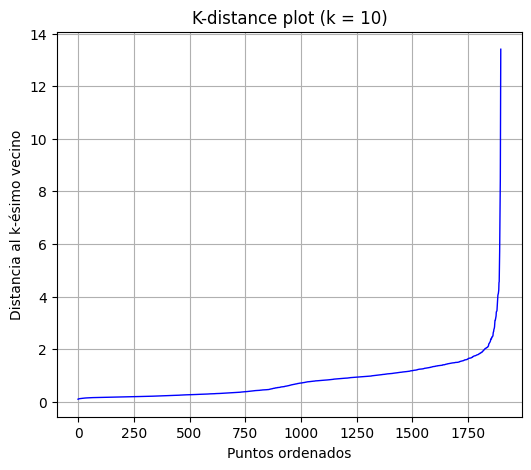

In [595]:
k_distances = k_distance_plot(X_scaled, min_samples=10)

In [596]:
# función que evalua el modelo dbscan para un epsilon y minPoints dado
def modelo_dbscan(X_scaled, eps, min_samples):
    """
    Aplica DBSCAN sobre los datos escalados.
    """

    dbscan = DBSCAN(eps=eps,min_samples=min_samples)

    labels = dbscan.fit_predict(X_scaled)

    return labels, dbscan

In [597]:
# función para evaluar dbscan con diferentes valores de epsilon
def evaluar_dbscan(X_scaled, eps_values, min_samples=10):
    resultados = {}

    for eps in eps_values:
        labels, _ = modelo_dbscan(X_scaled,eps=eps,min_samples=min_samples)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_ruido = np.sum(labels == -1)

        print(f"eps = {eps}")
        print(f"clusters detectados: {n_clusters}")
        print(f"puntos de ruido: {n_ruido}")
        print("-" * 30)

        resultados[eps] = labels

    return resultados

Viendo la gráfica del método de la k-ésima distancia, vemos que el codo se produce en torno a los valores de epsilon [1.5,2.0]. Vamos a evaluar nuestro modelo dbscan en torno a esos valores, para quedarnos con el que ofrece mejores resultados

In [598]:
eps_values = [1.5, 1.6, 1.7, 1.8, 1.9, 2.0]

resultados = evaluar_dbscan(
    X_scaled,
    eps_values,
    min_samples=10
)

eps = 1.5
clusters detectados: 1
puntos de ruido: 79
------------------------------
eps = 1.6
clusters detectados: 1
puntos de ruido: 61
------------------------------
eps = 1.7
clusters detectados: 1
puntos de ruido: 54
------------------------------
eps = 1.8
clusters detectados: 1
puntos de ruido: 49
------------------------------
eps = 1.9
clusters detectados: 1
puntos de ruido: 40
------------------------------
eps = 2.0
clusters detectados: 1
puntos de ruido: 36
------------------------------


Se observa que para valores de ε entre 1.5 y 2.0 el algoritmo DBSCAN detecta un único clúster correspondiente al cúmulo de las Pléyades, mientras que el número de puntos clasificados como ruido disminuye progresivamente al aumentar ε. Se selecciona un valor intermedio de ε que permite capturar la mayor parte de los miembros del cúmulo sin introducir una cantidad excesiva de estrellas de fondo.Epsilon = 1.7

In [599]:
labels, dbscan = modelo_dbscan(X_scaled,eps=1.7,min_samples=10)

In [600]:
df["cluster"] = labels

In [601]:
cluster_df = df[df["cluster"] == 0].copy()
ruido_df = df[df["cluster"] == -1].copy()
print("Número de estrellas en el cúmulo:", len(cluster_df))
print("Número de estrellas de ruido:", len(ruido_df))

Número de estrellas en el cúmulo: 1843
Número de estrellas de ruido: 54


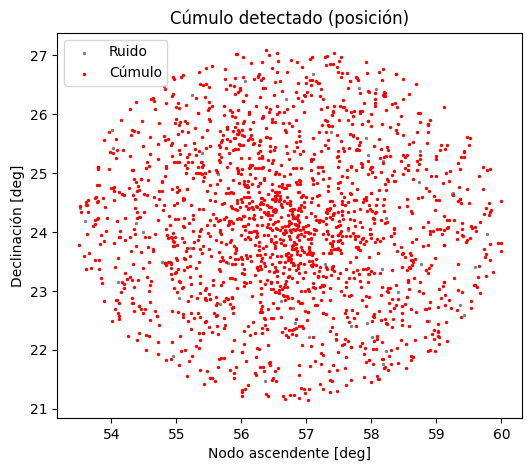

In [602]:
plt.figure(figsize=(6,5))

plt.scatter(ruido_df["ra"],ruido_df["dec"],s=2,color="gray",label="Ruido")

plt.scatter(cluster_df["ra"],cluster_df["dec"],s=2,color="red",label="Cúmulo")

plt.xlabel("Nodo ascendente [deg]")
plt.ylabel("Declinación [deg]")
plt.title("Cúmulo detectado (posición)")
plt.legend()
plt.show()

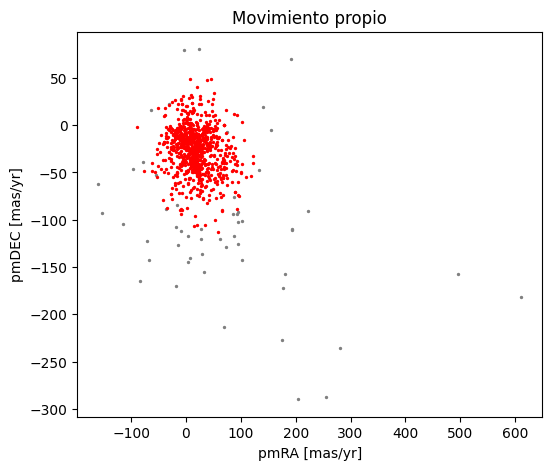

In [603]:
plt.figure(figsize=(6,5))

plt.scatter(ruido_df["pmra"],ruido_df["pmdec"],s=2,color="gray")

plt.scatter(cluster_df["pmra"],cluster_df["pmdec"],s=2,color="red")

plt.xlabel("pmRA [mas/yr]")
plt.ylabel("pmDEC [mas/yr]")
plt.title("Movimiento propio")
plt.show()

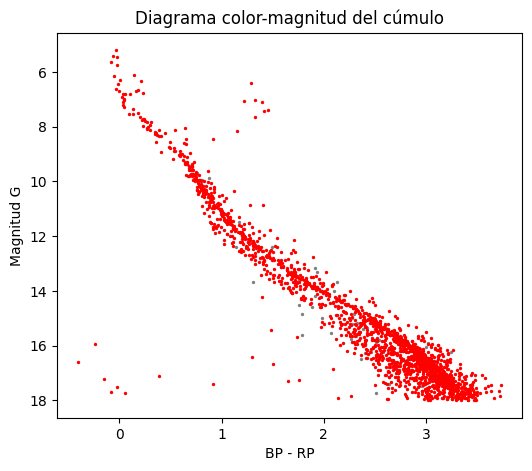

In [604]:
plt.figure(figsize=(6,5))

plt.scatter(ruido_df["bp_rp"],ruido_df["phot_g_mean_mag"],s=2,color="gray")

plt.scatter(cluster_df["bp_rp"],cluster_df["phot_g_mean_mag"],s=2,color="red")

plt.gca().invert_yaxis()

plt.xlabel("BP - RP")
plt.ylabel("Magnitud G")
plt.title("Diagrama color-magnitud del cúmulo")
plt.show()

La validez del clustering obtenido mediante DBSCAN se confirma al analizar las propiedades físicas de las estrellas clasificadas como pertenecientes al cúmulo. En primer lugar, en el espacio de movimiento propio (pmRA–pmDEC) se observa una concentración compacta y bien definida, característica de una población estelar con movimiento común. En segundo lugar, la distribución espacial (RA–DEC) muestra una clara sobredensidad en la región central, coherente con la estructura de un cúmulo abierto. Finalmente, en el diagrama color–magnitud (HR), las estrellas identificadas siguen una secuencia principal bien definida, lo que indica homogeneidad en edad, distancia y composición. En conjunto, estos tres análisis confirman que DBSCAN ha logrado aislar correctamente los miembros del cúmulo frente al fondo estelar.

In [605]:
print("Paralaje media:", cluster_df["parallax"].mean())
print("pmRA medio:", cluster_df["pmra"].mean())
print("pmDEC medio:", cluster_df["pmdec"].mean())

Paralaje media: 6.948512111875445
pmRA medio: 18.62870609168208
pmDEC medio: -36.184074346340125


In [606]:
#silueta
silueta_dbscan_pleyades = calcular_silueta(X_scaled, labels)
silueta_dbscan_pleyades

np.float64(0.5614919235206273)

# DBSCAN PERSEO

Con esto hemos validado con un caso sencillo nuestro modelo de DBSCAN. Vamos ahora a utilizar un caso un poco más complicado. La región de Perseo contiene dos cúmulos abiertos NGC 869 y NGC 884.

In [607]:
df_perseo = descargar_gaia_region(
    ra=35.0,
    dec=57.0,
    radio=2.5,
    g_max=17,
    parallax_min=0.2,
    parallax_max=1.0,
    max_rows=30000,
    output_csv="perseo_doble_cumulo_gaia_dr3.csv"
)

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]


In [608]:
variable = ["ra","dec","parallax", "pmra", "pmdec"]
df_vars = seleccionar_variables(df_perseo, variable)
df_vars.head()

,ra,dec,parallax,pmra,pmdec
0,36.112550,54.591050,0.634779,1.094607,-4.356096
1,35.986863,54.565508,0.897313,5.324354,-5.830354
2,36.033839,54.592143,0.371178,-1.379682,-0.225582
3,36.043744,54.603944,0.351078,-0.239440,-0.601456
4,36.123749,54.627690,0.524015,1.598959,-2.025573


In [609]:
# eda básico
df_vars.describe()

,ra,dec,parallax,pmra,pmdec
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,34.596943,55.745273,0.489220,0.059626,-1.201670
std,1.921648,0.721805,0.194629,3.076176,2.210777
min,31.166076,54.501182,0.200009,-17.140901,-37.373377
25%,33.050207,55.178475,0.337987,-1.476019,-2.124801
50%,34.284339,55.661999,0.437994,-0.307693,-1.048645
75%,35.959685,56.226916,0.608191,1.191666,-0.011490
max,39.587373,58.545316,0.999939,60.064824,12.985931


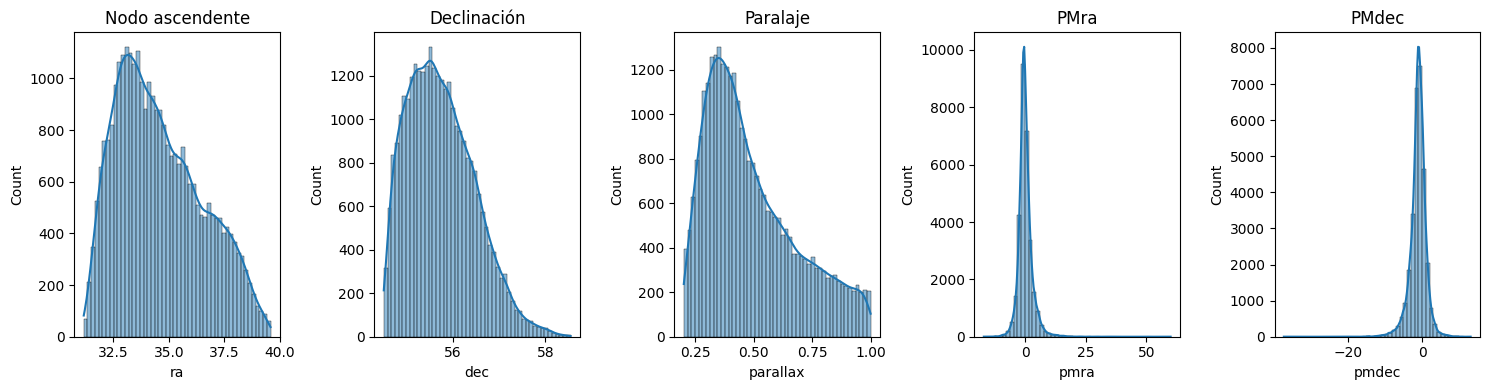

In [610]:
plot_histogramas(df_vars)


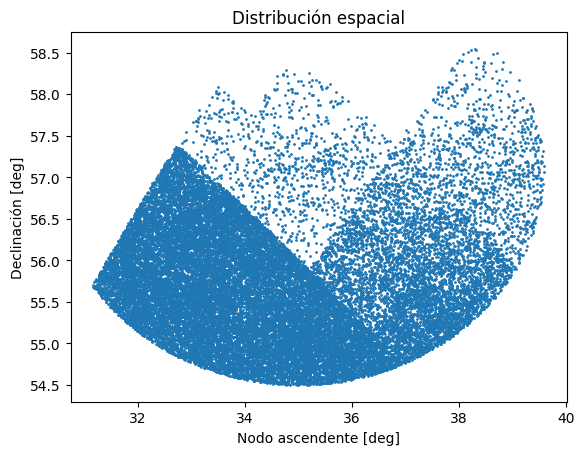

In [611]:
plt.scatter(df_perseo["ra"], df_perseo["dec"], s=1)
plt.xlabel("Nodo ascendente [deg]")
plt.ylabel("Declinación [deg]")
plt.title("Distribución espacial")
plt.show()

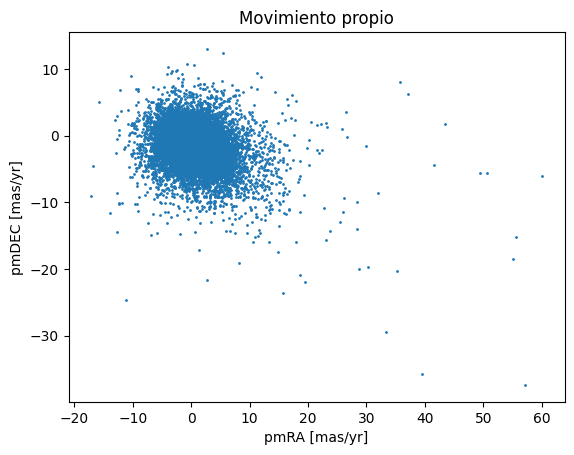

In [612]:
plt.scatter(df_perseo["pmra"], df_perseo["pmdec"], s=1)
plt.xlabel("pmRA [mas/yr]")
plt.ylabel("pmDEC [mas/yr]")
plt.title("Movimiento propio")
plt.show()

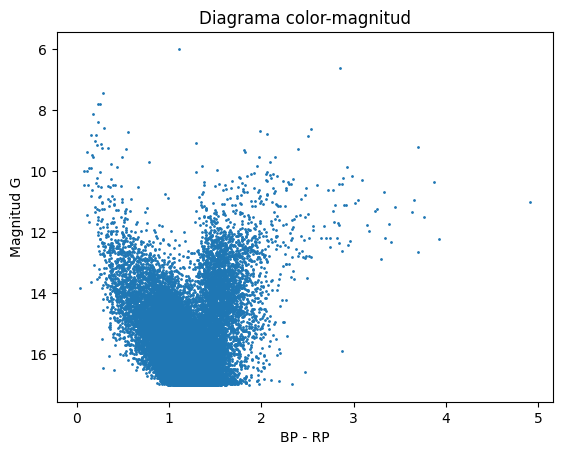

In [613]:
plt.scatter(df_perseo["bp_rp"],df_perseo["phot_g_mean_mag"],s=1)

plt.gca().invert_yaxis()
plt.xlabel("BP - RP")
plt.ylabel("Magnitud G")
plt.title("Diagrama color-magnitud")
plt.show()

In [614]:
for var in variable:
    comprobar_nulos(df_vars, var)

Valores nulos para la variable ra:

0
Valores nulos para la variable dec:

0
Valores nulos para la variable parallax:

0
Valores nulos para la variable pmra:

0
Valores nulos para la variable pmdec:

0


In [615]:
X_scaled = preparar_clustering(df_vars)

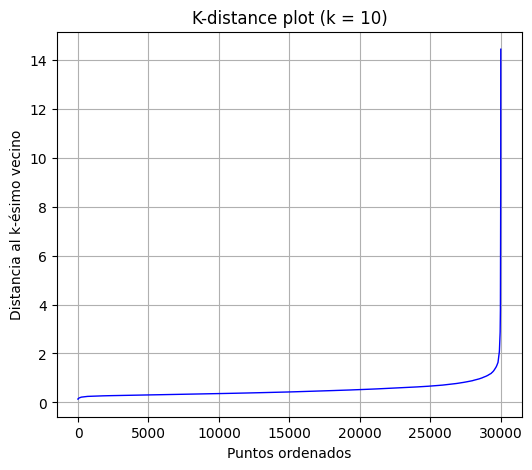

In [616]:
k_distances = k_distance_plot(X_scaled, min_samples=10)

In [617]:
eps_values = [1.3, 1.4, 1.5, 1.6, 1.7,1.8]
resultados = evaluar_dbscan(
    X_scaled,
    eps_values,
    min_samples=10
)

eps = 1.3
clusters detectados: 1
puntos de ruido: 205
------------------------------
eps = 1.4
clusters detectados: 1
puntos de ruido: 160
------------------------------
eps = 1.5
clusters detectados: 1
puntos de ruido: 129
------------------------------
eps = 1.6
clusters detectados: 1
puntos de ruido: 107
------------------------------
eps = 1.7
clusters detectados: 1
puntos de ruido: 91
------------------------------
eps = 1.8
clusters detectados: 1
puntos de ruido: 80
------------------------------


Vemos que dbscan tiene problemas para identificar clusters en conjuntos de datos con densidades significativamente diferentes. Vamos a desarrollar ahora un modelo de hdbscan, que fue desarrollado precisamente para solucionar este problema y poder especificar diferentes densidades dentro del mismo conjunto de datos.

# HDBSCAN PERSEO

In [618]:
#modelo hdbscan
def modelo_hdbscan(X_scaled, min_cluster_size, min_samples):
    """
    Aplica HDBSCAN sobre los datos escalados.

    Parámetros:
    - min_cluster_size: tamaño mínimo de un cúmulo.
    - min_samples: controla lo conservador que es el algoritmo.

    Devuelve:
    - labels: etiquetas de los clusters (-1 es ruido)
    - probabilities: probabilidad de pertenencia al cluster
    - clusterer: modelo entrenado
    """

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples
    )

    labels = clusterer.fit_predict(X_scaled)
    probabilities = clusterer.probabilities_

    return labels, probabilities, clusterer

Seleccionamos las mismas variables que utilizamos para estudiar el cúmulo de pleyades y escalamos los datos para una mejor interpretación del algoritmo.

In [619]:
variable = ["ra", "dec", "parallax", "pmra", "pmdec"]

df_vars = seleccionar_variables(df_perseo, variable)

X_scaled = preparar_clustering(df_vars)

Se evaluaron varios valores de min_cluster_size, que controla el tamaño mínimo de las agrupaciones detectadas por HDBSCAN. Se seleccionó el valor que producía estructuras astrométricamente coherentes y estables. El parámetro min_samples se mantuvo fijo para reducir la complejidad del ajuste."

In [620]:
def comparar_min_cluster_size(X_scaled, valores_min_cluster_size, min_samples=5):
    """
    Evalúa distintos valores de min_cluster_size para HDBSCAN.

    Para cada valor calcula:
    - número de clusters encontrados
    - número de puntos clasificados como ruido
    - porcentaje de ruido
    - tamaño de cada cluster

    Devuelve:
    - DataFrame con los resultados
    """

    resultados = []

    for mcs in valores_min_cluster_size:

        labels, probabilities, hdbscan_model = modelo_hdbscan(
            X_scaled,
            min_cluster_size=mcs,
            min_samples=min_samples
        )

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_ruido = np.sum(labels == -1)
        porcentaje_ruido = n_ruido / len(labels) * 100

        tamaños_clusters = pd.Series(labels).value_counts().sort_index()

        resultados.append({
            "min_cluster_size": mcs,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_ruido": n_ruido,
            "porcentaje_ruido": porcentaje_ruido,
            "tamaños_clusters": tamaños_clusters.to_dict()
        })

    return pd.DataFrame(resultados)

In [621]:
valores_min_cluster_size = [50, 80, 100, 150, 200]

resultados_hdbscan = comparar_min_cluster_size(
    X_scaled,
    valores_min_cluster_size=valores_min_cluster_size,
    min_samples=5
)

resultados_hdbscan

,min_cluster_size,min_samples,n_clusters,n_ruido,porcentaje_ruido,tamaños_clusters
0,50,5,2,23281,77.603333,"{-1: 23281, 0: 6663, 1: 56}"
1,80,5,4,29025,96.750000,"{-1: 29025, 0: 247, 1: 101, 2: 171, 3: 456}"
2,100,5,4,29025,96.750000,"{-1: 29025, 0: 247, 1: 101, 2: 171, 3: 456}"
3,150,5,3,29126,97.086667,"{-1: 29126, 0: 247, 1: 171, 2: 456}"
4,200,5,2,28788,95.960000,"{-1: 28788, 0: 247, 1: 965}"


In [622]:
# ejecutamos modelo hbdscan
labels, probabilities, hdbscan_model = modelo_hdbscan(
    X_scaled,
    min_cluster_size=80,
    min_samples=5)

Estudiamos el número de clusters detectados por dbscan y el número de estrellas en cada uno de ellos.

In [623]:
df_hdbscan = df_perseo.loc[df_vars.index].copy()

df_hdbscan["cluster_hdbscan"] = labels
df_hdbscan["prob_hdbscan"] = probabilities

In [624]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_ruido = sum(labels == -1)

print("Clusters detectados:", n_clusters)
print("Puntos de ruido:", n_ruido)
print("Puntos totales:", len(df_hdbscan))

Clusters detectados: 4
Puntos de ruido: 29025
Puntos totales: 30000


In [625]:
conteo_clusters = (
    df_hdbscan["cluster_hdbscan"]
    .value_counts()
    .sort_index()
)

print("\nNúmero de estrellas por cluster:")
print(conteo_clusters)


Número de estrellas por cluster:
cluster_hdbscan
-1    29025
 0      247
 1      101
 2      171
 3      456
Name: count, dtype: int64


In [626]:
df_clusters = df_hdbscan[df_hdbscan["cluster_hdbscan"] != -1].copy()

print("\nNúmero de estrellas clasificadas en clusters:")
print(len(df_clusters))


Número de estrellas clasificadas en clusters:
975


In [627]:
resumen_clusters = df_clusters.groupby("cluster_hdbscan")[
    ["ra", "dec", "parallax", "pmra", "pmdec", "prob_hdbscan"]
    ].agg(["count", "mean", "std"])

print("\nResumen por cluster:")
print(resumen_clusters)


Resumen por cluster:
                   ra                        dec                       \
                count       mean       std count       mean       std   
cluster_hdbscan                                                         
0                 247  35.008187  0.768859   247  54.907760  0.242888   
1                 101  33.321542  0.632927   101  55.398377  0.148864   
2                 171  35.536764  0.818894   171  57.112735  0.173267   
3                 456  33.284698  0.616659   456  56.371037  0.428693   

                parallax                      pmra                     pmdec  \
                   count      mean       std count      mean       std count   
cluster_hdbscan                                                                
0                    247  0.314820  0.038360   247 -0.223591  0.712587   247   
1                    101  0.295632  0.030459   101 -0.272961  0.617169   101   
2                    171  0.401757  0.025418   171 -0.579033  0.15

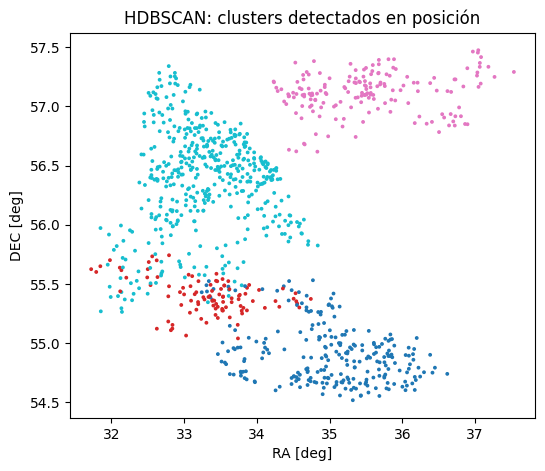

In [628]:
plt.figure(figsize=(6, 5))

plt.scatter(
    df_clusters["ra"],
    df_clusters["dec"],
    c=df_clusters["cluster_hdbscan"],
    s=3,
    cmap="tab10"
)

plt.xlabel("RA [deg]")
plt.ylabel("DEC [deg]")
plt.title("HDBSCAN: clusters detectados en posición")
plt.show()

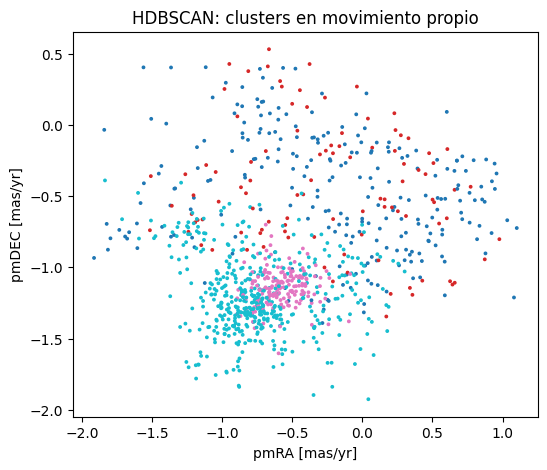

In [629]:
plt.figure(figsize=(6, 5))

plt.scatter(
    df_clusters["pmra"],
    df_clusters["pmdec"],
    c=df_clusters["cluster_hdbscan"],
    s=3,
    cmap="tab10"
)

plt.xlabel("pmRA [mas/yr]")
plt.ylabel("pmDEC [mas/yr]")
plt.title("HDBSCAN: clusters en movimiento propio")
plt.show()

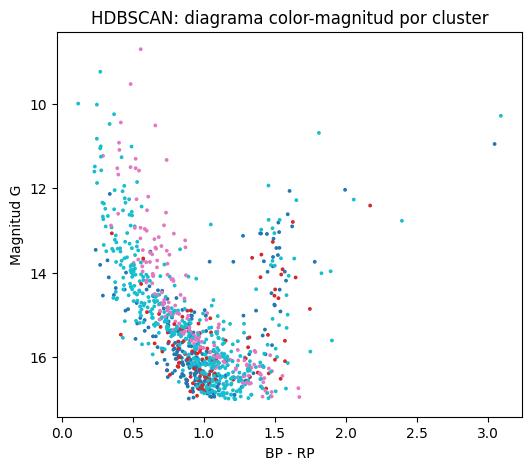

In [630]:
plt.figure(figsize=(6, 5))

plt.scatter(
    df_clusters["bp_rp"],
    df_clusters["phot_g_mean_mag"],
    c=df_clusters["cluster_hdbscan"],
    s=3,
    cmap="tab10"
)

plt.gca().invert_yaxis()
plt.xlabel("BP - RP")
plt.ylabel("Magnitud G")
plt.title("HDBSCAN: diagrama color-magnitud por cluster")
plt.show()

HDBSCAN permite identificar estructuras espacialmente coherentes que presentan además propiedades cinemáticas y fotométricas compatibles con cúmulos abiertos reales. A diferencia de DBSCAN, el algoritmo revela subestructuras internas y regiones de distinta densidad, proporcionando una representación más realista de la organización jerárquica del sistema estelar.

In [631]:
df_clusters.groupby("cluster_hdbscan")[
    ["ra", "dec", "parallax", "pmra", "pmdec"]].mean()

,ra,dec,parallax,pmra,pmdec
cluster_hdbscan,,,,,
0,35.008187,54.907760,0.314820,-0.223591,-0.478683
1,33.321542,55.398377,0.295632,-0.272961,-0.447705
2,35.536764,57.112735,0.401757,-0.579033,-1.139942
3,33.284698,56.371037,0.378999,-0.748698,-1.202653


Los centroides muestran que HDBSCAN identifica varias subestructuras con propiedades astrométricas diferenciadas. Los clusters 1 y 3 presentan valores similares de paralaje y movimiento propio, lo que sugiere que podrían estar asociados a las componentes principales del doble cúmulo de Perseo. Los clusters 0 y 2, aunque espacialmente próximos a la región analizada, muestran diferencias más claras en paralaje o posición, por lo que podrían corresponder a subestructuras, halo del sistema o contaminación residual del campo estelar.

In [632]:
dbcv_hdbscan = validity_index(
    X_scaled.astype(np.float64),
    labels.astype(int)
)

print("DBCV HDBSCAN Perseo:", dbcv_hdbscan)

DBCV HDBSCAN Perseo: -0.013092912002456908
